# B-8802B — política de retreino: últimos resultados (out/2026)

**Em uma frase:** o modelo fica fixo; um monitor semanal avisa quando o normal do equipamento muda; com a confirmação
da operação, entram modelos novos com **1, 3, 6 e 12 meses** de dado depois da mudança, e depois o modelo fica fixo de
novo até a próxima mudança.

**O que mudou desde o último notebook**
1. **Calendário do retreino:** era todo mês até 12 meses; agora são só 4 modelos (1, 3, 6 e 12 meses). O resultado é
   quase o mesmo, com 3 trocas em vez de 11 (seção 3).
2. **Alerta do modelo × aviso de mudança** separados nas figuras: são dois sinais diferentes (seção 1).
3. **Falha de 2022 olhada com mais cuidado:** todos os alertas de cada modelo, e comparação com uma regra simples de
   limite (seção 4).
4. **Teste da janela deslizante** rodado no ClearML (task f65c0851), incluindo a ideia de usar 1 mês novo + 11 do ano
   anterior (seção 5).

Todos os modelos aqui vêm do replay rodado no ClearML (task 28fb7c95): retreinos sobre o dado real de jan/2025 a
ago/2026, como se a política estivesse em produção.

In [1]:
import sys, json, shutil, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
%config InlineBackend.figure_format = "retina"
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DEP = PROJECT_ROOT / "deploy_v2/Transpetro"; sys.path.insert(0, str(DEP))
import simpred_inference as si
from transpetro_modelos.drift import monitor as mon
from transpetro_modelos.drift.residuo import ResidualLevelDetector

VERMELHO, LARANJA, CINZA, VERDE, AZUL = "tab:red", "darkorange", "darkgray", "green", "tab:blue"
R = PROJECT_ROOT / "results/replay_pipeline"     # python scripts/replay_pipeline.py --baixar 28fb7c95e4df46b38782472e1837f857 --out results/replay_pipeline
DADOS = DEP / "B-8802B-2025/dados/2025_2026/data_2025-01-01_2026-08-10_raw.csv"
raw = si.carregar_dados(DADOS); FIM = raw.index.max(); INI = raw.index.min()
raw22 = si.carregar_dados(next((DEP / "B-8802B/dados").rglob("*_raw.csv")))
FALHA22 = pd.Timestamp("2022-07-06 10:00")
B_2022 = DEP / "B-8802B/modelos/model_2022-05-15_2022-07-21_VAE"

# o modelo de 2022 com as mesmas regras de alerta (alarme de 1 h ou mais), numa cópia
B_ANTIGO = R / "modelo_2022_regras_novas"
if not B_ANTIGO.exists(): shutil.copytree(B_2022, B_ANTIGO)
a = json.loads((B_ANTIGO / "alarm.json").read_text())
a.update({"debounce_window": 20, "debounce_min": 15, "persistence_mode": "time", "persistence_step": "5min", "min_alert_hours": 1.0})
(B_ANTIGO / "alarm.json").write_text(json.dumps(a, indent=1, ensure_ascii=False))

resumo = pd.read_csv(R / "resumo.csv")
MODELO = {int(r.etapa): (PROJECT_ROOT / r.bundle, pd.Timestamp(r.treino_fim)) for r in resumo.itertuples() if r.aprovado}

def alerta(bundle, df, ini=None, fim=None):
    ini = ini or df.index.min(); fim = fim or df.index.max()
    seg = df.loc[ini - pd.Timedelta(days=1): fim]
    r = si.prever(bundle, si.carregar_modelo(bundle), si.preprocessar(bundle, seg), df_bruto=seg)["alerta"]
    return r[(r.index >= ini) & (r.index <= fim)]

def blocos(flag):
    a = flag[flag]
    if a.empty: return []
    return [(e.index.min(), e.index.max()) for _, e in a.groupby((a.index.to_series().diff() > pd.Timedelta("1h")).cumsum())]

def sistema(meses):
    """o que o sistema teria alertado com modelos novos nesses meses de dado (antes do 1º: o modelo de 2022)"""
    agenda = [(B_ANTIGO, INI)] + [MODELO[m] for m in meses]
    return pd.concat([alerta(b, raw, ini, agenda[i + 1][1] - pd.Timedelta(minutes=1) if i + 1 < len(agenda) else FIM)
                      for i, (b, ini) in enumerate(agenda)])

MESES = [1, 3, 6, 12]
sis = sistema(MESES); antigo = alerta(B_ANTIGO, raw)
T_AVISO = mon.ks_daily_fires(DADOS, B_2022)[0][0]
T_RETREINO, T_12 = MODELO[1][1], MODELO[12][1]
d12 = MODELO[12][0]
todos = mon._sem_congelado(d12, mon._temporal_steps(d12, raw.loc[T_12:], todos_sensores=True))
T_AVISO2 = ResidualLevelDetector.from_dict(json.loads((d12 / "residual_ref.json").read_text())["detectors"][0]).scan(todos)[1][0]
print("pronto")

pronto


## 0. Como funciona (metodologia em poucas linhas)

| Parte | Como é feita |
|---|---|
| **Modelo** | VAE (autoencoder variacional) com 5 sensores: pressão de sucção e de descarga, vibração do mancal LA e LNA, temperatura do mancal LA. Aprende a operação normal (só com a bomba operando) e tenta reconstruir os sensores; erro alto = anomalia. O de produção foi treinado com os 12 meses de 2025, hiperparâmetros por AutoML no ClearML (camadas 128-64-32, latente 16). |
| **Alerta do modelo** | Limiar = média + 6,5 desvios do erro no período normal. Alarme quando o erro passa do limiar em 15 de 20 pontos de 5 min (sem contar a bomba parada); **alerta** para a operação só se o alarme durar **1 hora ou mais**. |
| **Aviso de mudança** (monitor semanal) | (a) Teste KS: compara a distribuição diária de cada sensor com o período de treino do modelo em produção; avisa se 3 de 5 dias ficam fora. (b) Resíduo: a temperatura do mancal LA é comparada com a esperada pelo motor e pelas pressões (regressão), o que tira o efeito da estação do ano. (c) Dado congelado (3 ou mais sensores parados por 12 h) é falha de aquisição: sai das contas e é avisado à parte. |
| **Retreino** | Só depois que a operação confirma que é um normal novo, e só com dado **depois** da mudança. Modelos com 1, 3, 6 e 12 meses; depois fica fixo até a próxima mudança. Cada vez: 12 candidatos (4 configurações × 3 sementes) no ClearML. |
| **Teste antes de entrar** | Poucos alertas falsos na validação (≤ 0,5 %), alertar a falha real de 2022 pelo menos 0,5 dia antes, e detectar uma falha simulada no período novo. Quem não passa não entra. |
| **No intervalo** (do aviso até o modelo de 1 mês) | O modelo atual continua rodando; os alertas dele valem **com ressalva** (podem ser só o normal novo). |

## 1. O resultado: alerta do modelo × aviso de mudança

Em cima, **alerta do modelo** por semana (nesse período não houve falha: todo alerta é falso). Cinza: se o modelo de
2022 tivesse ficado. Vermelho: com a política. Embaixo, o **monitor de mudança** e quando entrou cada modelo novo.

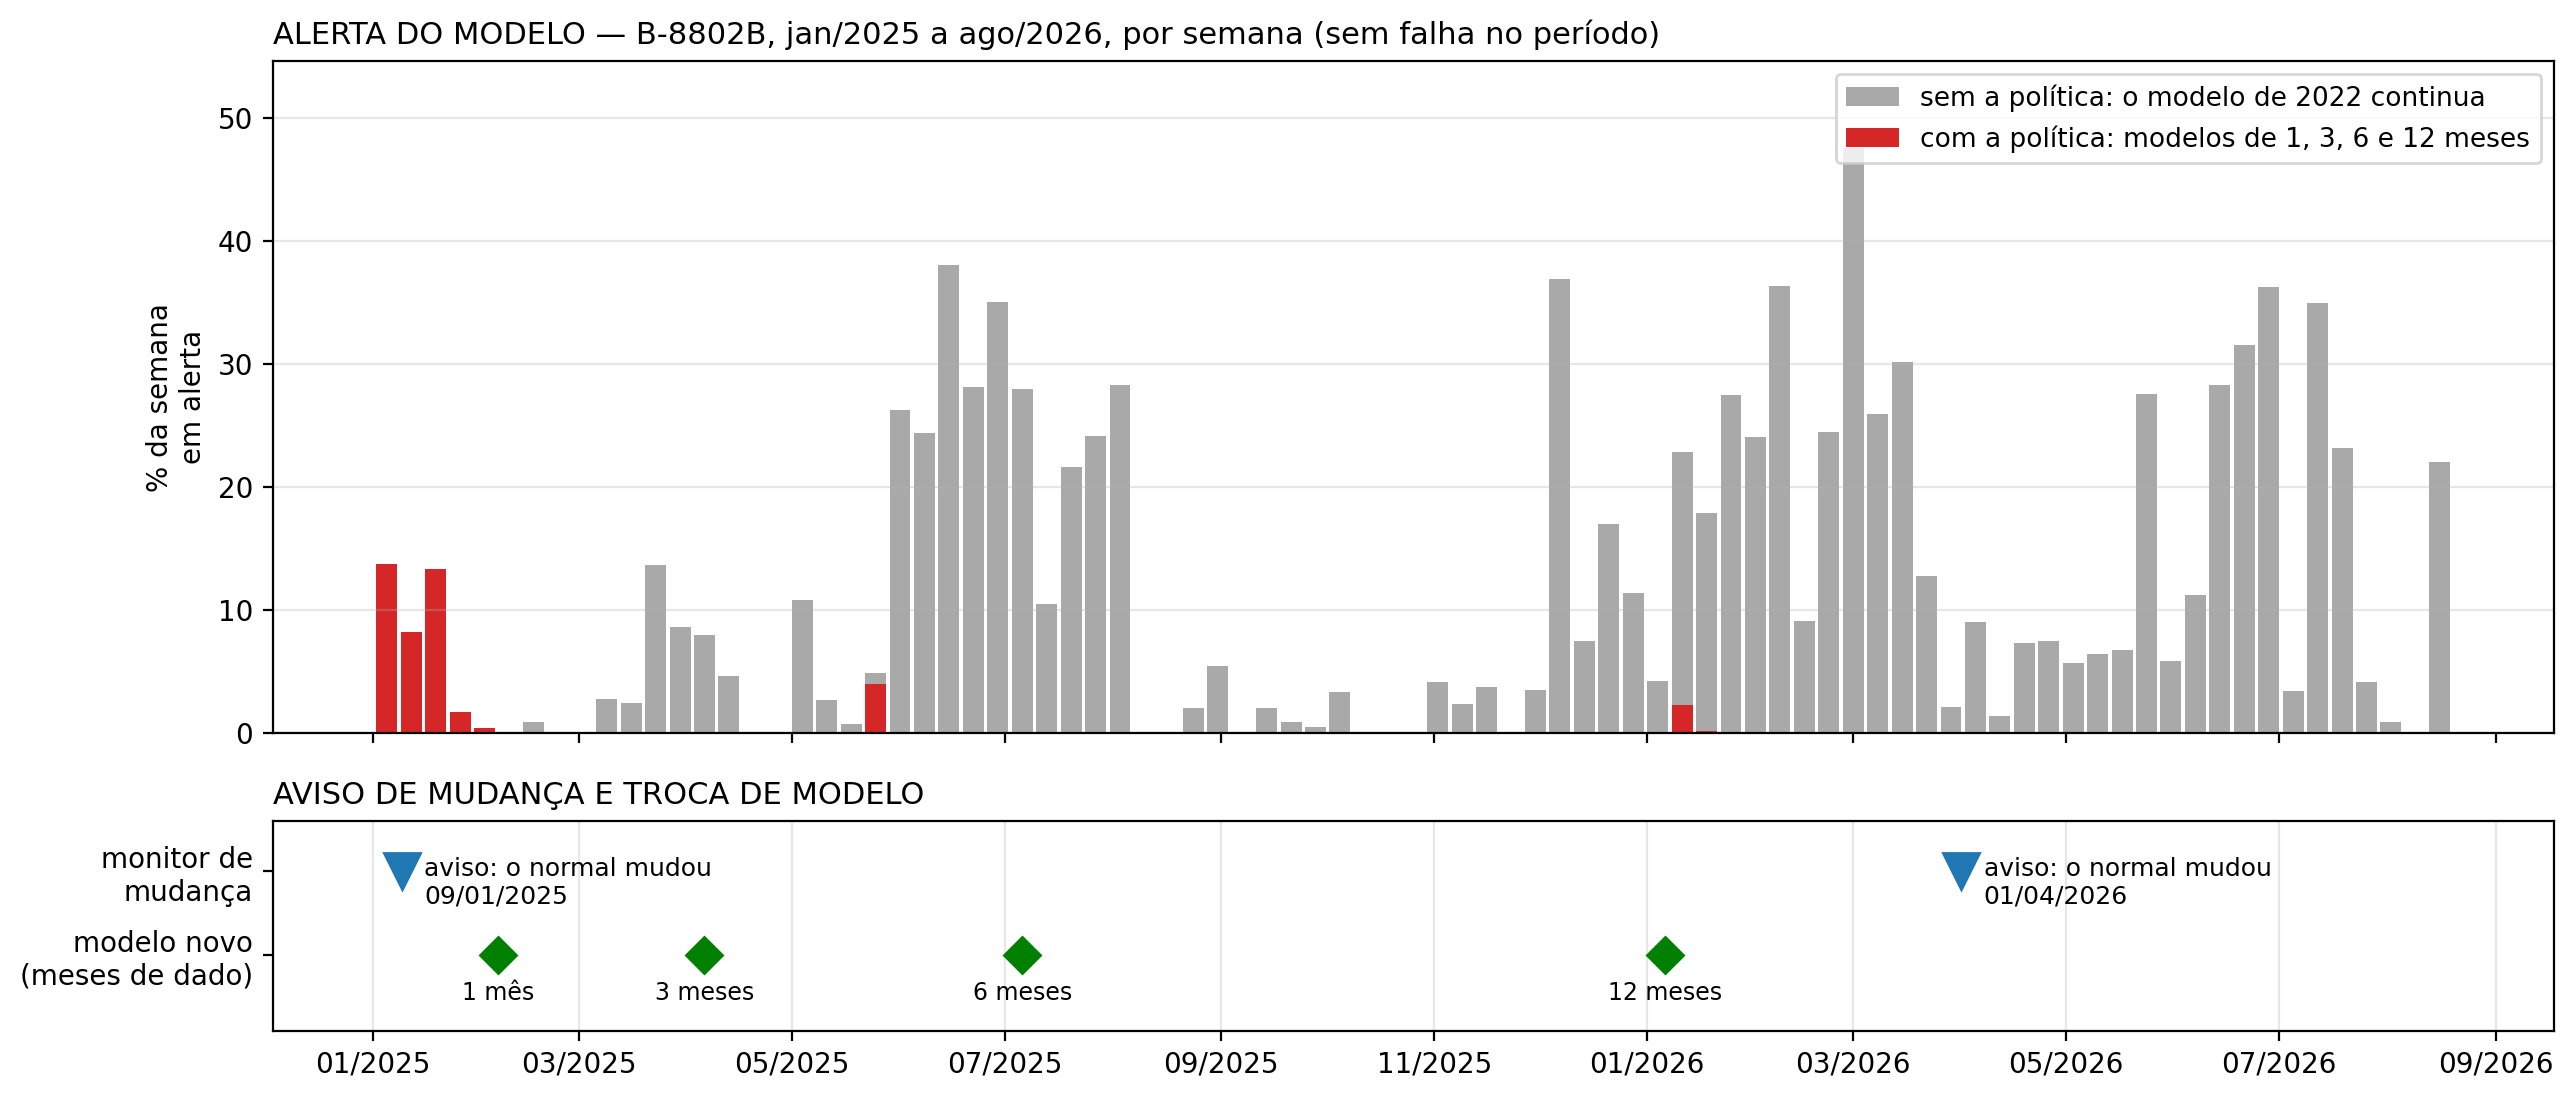

modelo de 2022 mantido: 269 alertas, 12.0 % do tempo
com a política, depois do 1º modelo novo: 3 alertas, 0.09 % do tempo: 19/05/2025, 10/01/2026, 17/01/2026
avisos de mudança: 09/01/2025 (depois do reparo) e 01/04/2026 (mancal LA, depois da parada de 27/03/2026)


In [2]:
sem = lambda r: 100 * r.groupby(pd.Grouper(freq="W")).mean()
s_ant, s_sis = sem(antigo), sem(sis)
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 5.6), sharex=True, gridspec_kw={"height_ratios": [3.2, 1]})
ax.bar(s_ant.index, s_ant.values, width=6, color=CINZA, label="sem a política: o modelo de 2022 continua")
ax.bar(s_sis.index, s_sis.values, width=6, color=VERMELHO, label="com a política: modelos de 1, 3, 6 e 12 meses")
ax.set_ylim(0, s_ant.max() * 1.15); ax.set_ylabel("% da semana\nem alerta"); ax.grid(alpha=0.3, axis="y")
ax.legend(loc="upper right", fontsize=9.5)
ax.set_title("ALERTA DO MODELO — B-8802B, jan/2025 a ago/2026, por semana (sem falha no período)", loc="left", fontsize=11)
for t in [T_AVISO, T_AVISO2]:
    ax2.plot(t, 1, marker="v", markersize=13, color=AZUL)
    ax2.annotate(f"aviso: o normal mudou\n{t:%d/%m/%Y}", (t, 1), xytext=(8, -4), textcoords="offset points", fontsize=9, va="center")
for m in MESES:
    ax2.plot(MODELO[m][1], 0, marker="D", markersize=9, color=VERDE)
    ax2.annotate(f"{m} {'mês' if m == 1 else 'meses'}", (MODELO[m][1], 0), xytext=(0, -16), textcoords="offset points", fontsize=8.5, ha="center")
ax2.set_ylim(-0.9, 1.6); ax2.set_yticks([1, 0]); ax2.set_yticklabels(["monitor de\nmudança", "modelo novo\n(meses de dado)"])
ax2.grid(alpha=0.3, axis="x"); ax2.set_title("AVISO DE MUDANÇA E TROCA DE MODELO", loc="left", fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y")); plt.tight_layout(); plt.show()
dep = sis[sis.index >= T_RETREINO]
print(f"modelo de 2022 mantido: {len(blocos(antigo))} alertas, {100 * antigo.mean():.1f} % do tempo")
print(f"com a política, depois do 1º modelo novo: {len(blocos(dep))} alertas, {100 * dep.mean():.2f} % do tempo:",
      ", ".join(f"{a:%d/%m/%Y}" for a, b in blocos(dep)))
print(f"avisos de mudança: {T_AVISO:%d/%m/%Y} (depois do reparo) e {T_AVISO2:%d/%m/%Y} (mancal LA, depois da parada de 27/03/2026)")

**Leitura:** os dois avisos vêm do **monitor de mudança**, não do modelo de anomalia, e de detectores diferentes:
o de 09/01/2025 é o **teste KS (M6)**, comparando 2025 com o treino do modelo de 2022; o de 01/04/2026 é o
**detector de temperatura do mancal (M8)**, comparando com o treino do modelo de 2025 (o KS não disparou em 2026).

O aviso de 09/01/2025 levou ao modelo de 1 mês em 06/02/2025, e os alertas falsos praticamente
pararam. O aviso de 01/04/2026 ainda não virou retreino porque a política espera a operação confirmar o que foi feito
nas paradas de 17/03 e 27/03/2026; o modelo atual segue sem alertar à toa.

**Ponto fraco:** o mês entre o aviso e o 1º modelo novo (jan/2025), com o modelo antigo ainda alertando à toa.

## 2. Precisa refazer todo mês?

Mesmos modelos do replay, trocados em calendários diferentes. Período: do 1º modelo novo (06/02/2025) até ago/2026.

In [3]:
linhas = []
for nome, meses in [("todo mês até 12", list(range(1, 13))), ("1, 3, 6 e 12 meses (adotado)", MESES),
                    ("1 e 12 meses", [1, 12]), ("só o de 1 mês, nunca refaz", [1])]:
    s = sistema(meses); s = s[s.index >= T_RETREINO]
    linhas.append({"calendário": nome, "trocas de modelo": len(meses) - 1, "alertas falsos": len(blocos(s)),
                   "% do tempo em alerta": round(100 * s.mean(), 2)})
pd.DataFrame(linhas).set_index("calendário")

,trocas de modelo,alertas falsos,% do tempo em alerta
calendário,,,
todo mês até 12,11,2,0.04
"1, 3, 6 e 12 meses (adotado)",3,3,0.09
1 e 12 meses,1,10,0.36
"só o de 1 mês, nunca refaz",0,57,1.93


O modelo de 1 mês sozinho não aguenta: só conhece aquele mês e estranha quando a estação muda. Mas refazer todo
mês também não é preciso: com 1, 3, 6 e 12 meses o resultado é quase igual, com 3 trocas em vez de 11.

## 3. A falha de 2022: todos os alertas de cada modelo

Nenhum dos modelos novos viu 2022 no treino. À esquerda, o modelo de 12 meses na semana da falha; à direita, todos
os alertas de cada modelo de 15/05 até a quebra (vermelho: na falha; laranja: alerta falso antes). A linha tracejada
é quando uma **regra simples de limite** (vibração do mancal LA acima do maior valor normal, p99,9, em média horária)
teria disparado.

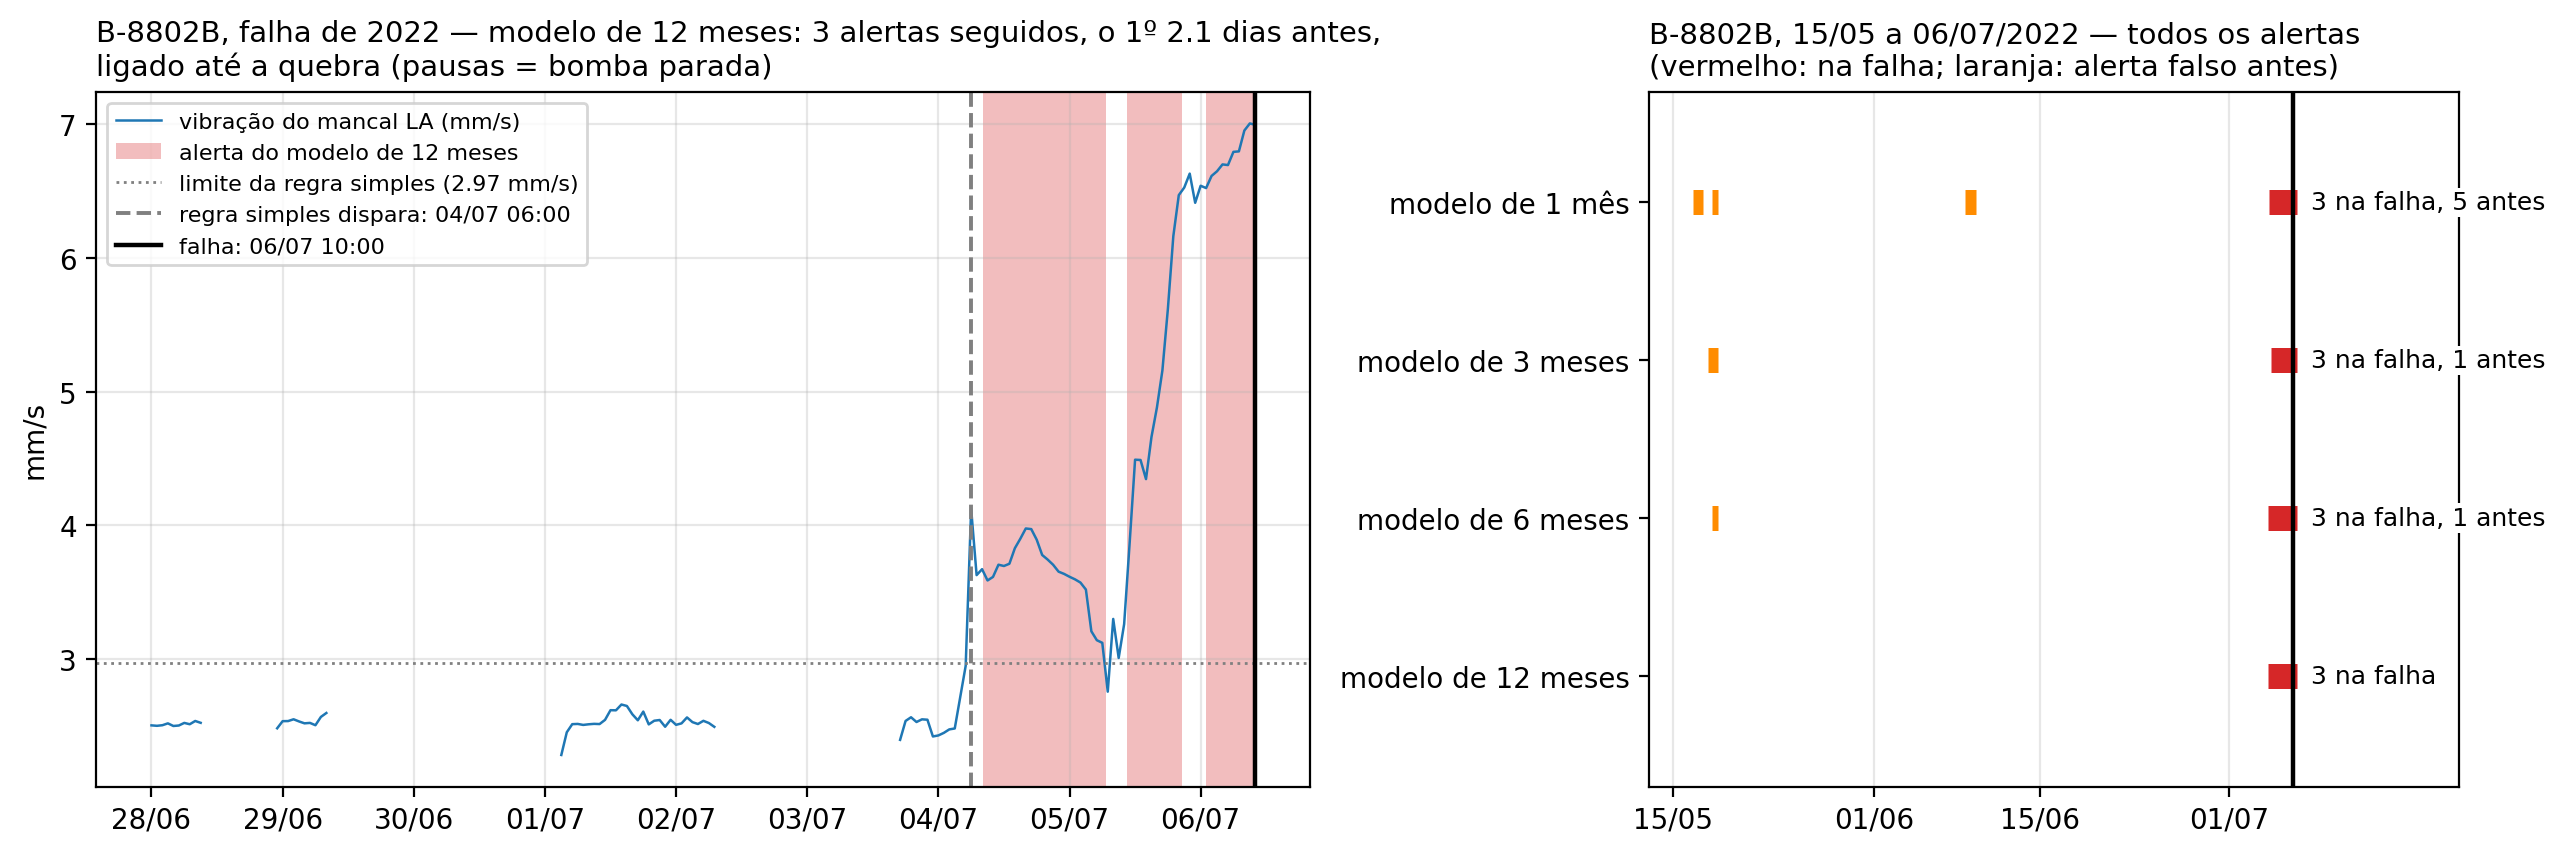

modelo de  1 meses: 16/05 16:05 (13 h), 18/05 06:30 (5 h), 08/06 17:10 (1 h), 08/06 21:00 (4 h), 09/06 05:20 (1 h), 04/07 08:45 (22 h), 05/07 10:40 (10 h), 06/07 00:55 (9 h)
modelo de  3 meses: 17/05 22:40 (13 h), 04/07 12:25 (18 h), 05/07 10:40 (10 h), 06/07 00:55 (9 h)
modelo de  6 meses: 18/05 06:30 (5 h), 04/07 08:10 (21 h), 05/07 10:30 (10 h), 06/07 00:55 (9 h)
modelo de 12 meses: 04/07 08:05 (23 h), 05/07 10:35 (10 h), 06/07 00:55 (9 h)
regra simples (vibração LA > 2.97 mm/s): 04/07 06:00, 2.2 dias antes
vibração LA, média diária (mm/s): 27/06: 2.58, 28/06: 2.51, 29/06: 2.54, 01/07: 2.55, 02/07: 2.53, 03/07: 2.52, 04/07: 3.47, 05/07: 4.41, 06/07: 6.73


In [4]:
op22 = raw22[raw22["Pressão Descarga"] > 35]
vib = op22["Vibração Bomba LA"]; lim = vib.loc[:"2022-06-25"].quantile(0.999)
h = vib.loc["2022-06-25":FALHA22].resample("1h").mean(); T_REGRA = h[h > lim].index.min()
al = {m: alerta(MODELO[m][0], raw22).loc[:FALHA22] for m in MESES}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.5, 1]})
v = op22["Vibração Bomba LA"].loc["2022-06-28":FALHA22].resample("1h").mean()
axes[0].plot(v.index, v, linewidth=0.9, color=AZUL, label="vibração do mancal LA (mm/s)")
b12 = blocos(al[12].loc["2022-06-28":])
for n, (a, b) in enumerate(b12):
    axes[0].axvspan(a, b, color=VERMELHO, alpha=0.3, linewidth=0, label="alerta do modelo de 12 meses" if n == 0 else None)
axes[0].axhline(lim, color="gray", linewidth=1, linestyle=":", label=f"limite da regra simples ({lim:.2f} mm/s)")
axes[0].axvline(T_REGRA, color="gray", linewidth=1.4, linestyle="--", label=f"regra simples dispara: {T_REGRA:%d/%m %H:%M}")
axes[0].axvline(FALHA22, color="black", linewidth=1.6, label="falha: 06/07 10:00")
axes[0].set_title(f"B-8802B, falha de 2022 — modelo de 12 meses: {len(b12)} alertas seguidos, o 1º "
                  f"{(FALHA22 - b12[0][0]).total_seconds() / 86400:.1f} dias antes,\nligado até a quebra (pausas = bomba parada)", loc="left", fontsize=10.5)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m")); axes[0].set_ylabel("mm/s"); axes[0].legend(loc="upper left", fontsize=8)
axes[0].grid(alpha=0.3)
ax = axes[1]
for i, m in enumerate(MESES):
    y = len(MESES) - 1 - i
    bl = blocos(al[m]); n_f = sum(a >= FALHA22 - pd.Timedelta(days=3) for a, _ in bl)
    for a, b in bl:
        ax.plot([a, b + pd.Timedelta(hours=8)], [y, y], color=VERMELHO if a >= FALHA22 - pd.Timedelta(days=3) else LARANJA,
                linewidth=9, solid_capstyle="butt")
    ax.text(FALHA22 + pd.Timedelta(days=1.5), y, f"{n_f} na falha" + (f", {len(bl) - n_f} antes" if len(bl) > n_f else ""),
            va="center", fontsize=9, bbox=dict(facecolor="white", edgecolor="none", pad=1))
ax.axvline(FALHA22, color="black", linewidth=1.6)
ax.set_yticks(range(len(MESES))); ax.set_yticklabels([f"modelo de {m} {'mês' if m == 1 else 'meses'}" for m in MESES[::-1]])
ax.set_xlim(pd.Timestamp("2022-05-13"), FALHA22 + pd.Timedelta(days=14)); ax.set_ylim(-0.7, len(MESES) - 0.3)
ax.set_xticks(pd.to_datetime(["2022-05-15", "2022-06-01", "2022-06-15", "2022-07-01"]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m")); ax.grid(alpha=0.3, axis="x")
ax.set_title("B-8802B, 15/05 a 06/07/2022 — todos os alertas\n(vermelho: na falha; laranja: alerta falso antes)", loc="left", fontsize=10.5)
plt.tight_layout(); plt.show()
for m in MESES:
    print(f"modelo de {m:2d} meses:", ", ".join(f"{a:%d/%m %H:%M} ({(b - a).total_seconds() / 3600:.0f} h)" for a, b in blocos(al[m])))
print(f"regra simples (vibração LA > {lim:.2f} mm/s): {T_REGRA:%d/%m %H:%M}, {(FALHA22 - T_REGRA).total_seconds() / 86400:.1f} dias antes")
print("vibração LA, média diária (mm/s):", ", ".join(f"{t:%d/%m}: {x:.2f}" for t, x in vib.loc["2022-06-27":FALHA22].resample("1D").mean().dropna().items()))

**Leitura honesta:**
- Não é "um alarme só": os 4 modelos alertam em 04/07 de manhã e o alerta **fica ligado até a quebra** (3 trechos;
  as pausas são a bomba parada).
- O modelo **detecta a falha quando ela começa**, não semanas antes: em junho o erro ficou entre 10 % e 35 % do limiar
  e a vibração estava estável (~2,5 mm/s). A falha se desenvolveu em 2 dias.
- Para **essa** falha, brusca e muito visível na vibração, uma regra simples de limite dispararia praticamente junto.
  O valor do modelo sobre um limite (ver os sensores juntos, menos alarme falso) **ainda não foi medido**.
- Os modelos de 1, 3 e 6 meses ainda dão alertas falsos em maio/junho de 2022; o de 12 meses, nenhum.

## 4. Março de 2026: o que aconteceu e o que cada detector viu

São **três detectores diferentes**, e é importante não misturar:

| detector | o que pergunta | o que gera |
|---|---|---|
| **modelo de anomalia** (VAE) | "tem algo anormal nos sensores agora?" | **alerta** para a operação |
| **teste KS** (monitor, M6) | "a distribuição diária de cada sensor ainda é a do treino?" | **aviso de mudança** |
| **resíduo de temperatura** (monitor, M8) | "a temperatura do mancal LA está onde o motor e as pressões dizem que deveria?" (tira a estação) | **aviso de mudança** |

**Filtro de bomba ligada** (o mesmo para os três, no `pipeline.json` do bundle): só entra dado com pressão de descarga
acima de 35 bar; saem os 90 min depois de cada partida (aquecimento), 90 min depois de manobras bruscas de pressão e
os trechos de dado congelado. Primeiro, a pergunta: a mudança de 2026 é efeito da bomba desligada?

In [5]:
on = raw["Pressão Descarga"] > 35
corr = on.ne(on.shift()).cumsum()
runs = [(s.index[0], s.index[-1]) for _, s in on.groupby(corr) if s.iloc[0]]
m = []
for a, b in runs:                                  # junta corridas separadas por menos de 30 min
    if m and a - m[-1][1] < pd.Timedelta("30min"): m[-1][1] = b
    else: m.append([a, b])
runs = pd.DataFrame(m, columns=["ini", "fim"]); runs["h"] = (runs.fim - runs.ini).dt.total_seconds() / 3600
runs = runs[runs.h >= 0.25]
desde = pd.Series(np.nan, index=raw.index)          # horas desde a partida, para cada minuto ligado
for r in runs.itertuples():
    sel = (raw.index >= r.ini) & (raw.index <= r.fim); desde[sel] = (raw.index[sel] - r.ini).total_seconds() / 3600
abr_jul = lambda s, ano: s[(s.index.year == ano) & s.index.month.isin([4, 5, 6, 7])]
op_tab = pd.DataFrame({
    ano: {"% do tempo com a bomba ligada": round(100 * abr_jul(on, ano).mean()),
          "duração mediana de cada corrida (h)": round(runs[(runs.ini.dt.year == ano) & runs.ini.dt.month.isin([4, 5, 6, 7])].h.median()),
          "mancal LA, 1,5 a 3 h depois da partida (°C)": round(abr_jul(raw["Temperatura Bomba LA"][(desde > 1.5) & (desde <= 3)], ano).median(), 1),
          "mancal LA, mais de 48 h depois da partida (°C)": round(abr_jul(raw["Temperatura Bomba LA"][desde > 48], ano).median(), 1)}
    for ano in (2025, 2026)})
op_tab.columns = ["abr–jul/2025", "abr–jul/2026"]; op_tab

,abr–jul/2025,abr–jul/2026
% do tempo com a bomba ligada,81.0,93.0
duração mediana de cada corrida (h),65.0,78.0
"mancal LA, 1,5 a 3 h depois da partida (°C)",51.0,44.9
"mancal LA, mais de 48 h depois da partida (°C)",52.7,46.4


**Não é efeito de bomba desligada:** em 2026 a bomba ficou **mais** tempo ligada, com corridas mais longas, e o
mancal LA está mais frio **mesmo com mais de 48 h ligada**. Os 90 min de corte depois da partida bastam (com 1,5 a
3 h o mancal já está perto do regime).

Agora, dia a dia de fevereiro a abril de 2026, o mancal e o que cada detector fez. A figura usa **exatamente o dado
que o modelo e o monitor veem**, depois de todos os filtros, e só dias com pelo menos 6 h de operação (de 20 a
23/04 a bomba ficou parada).

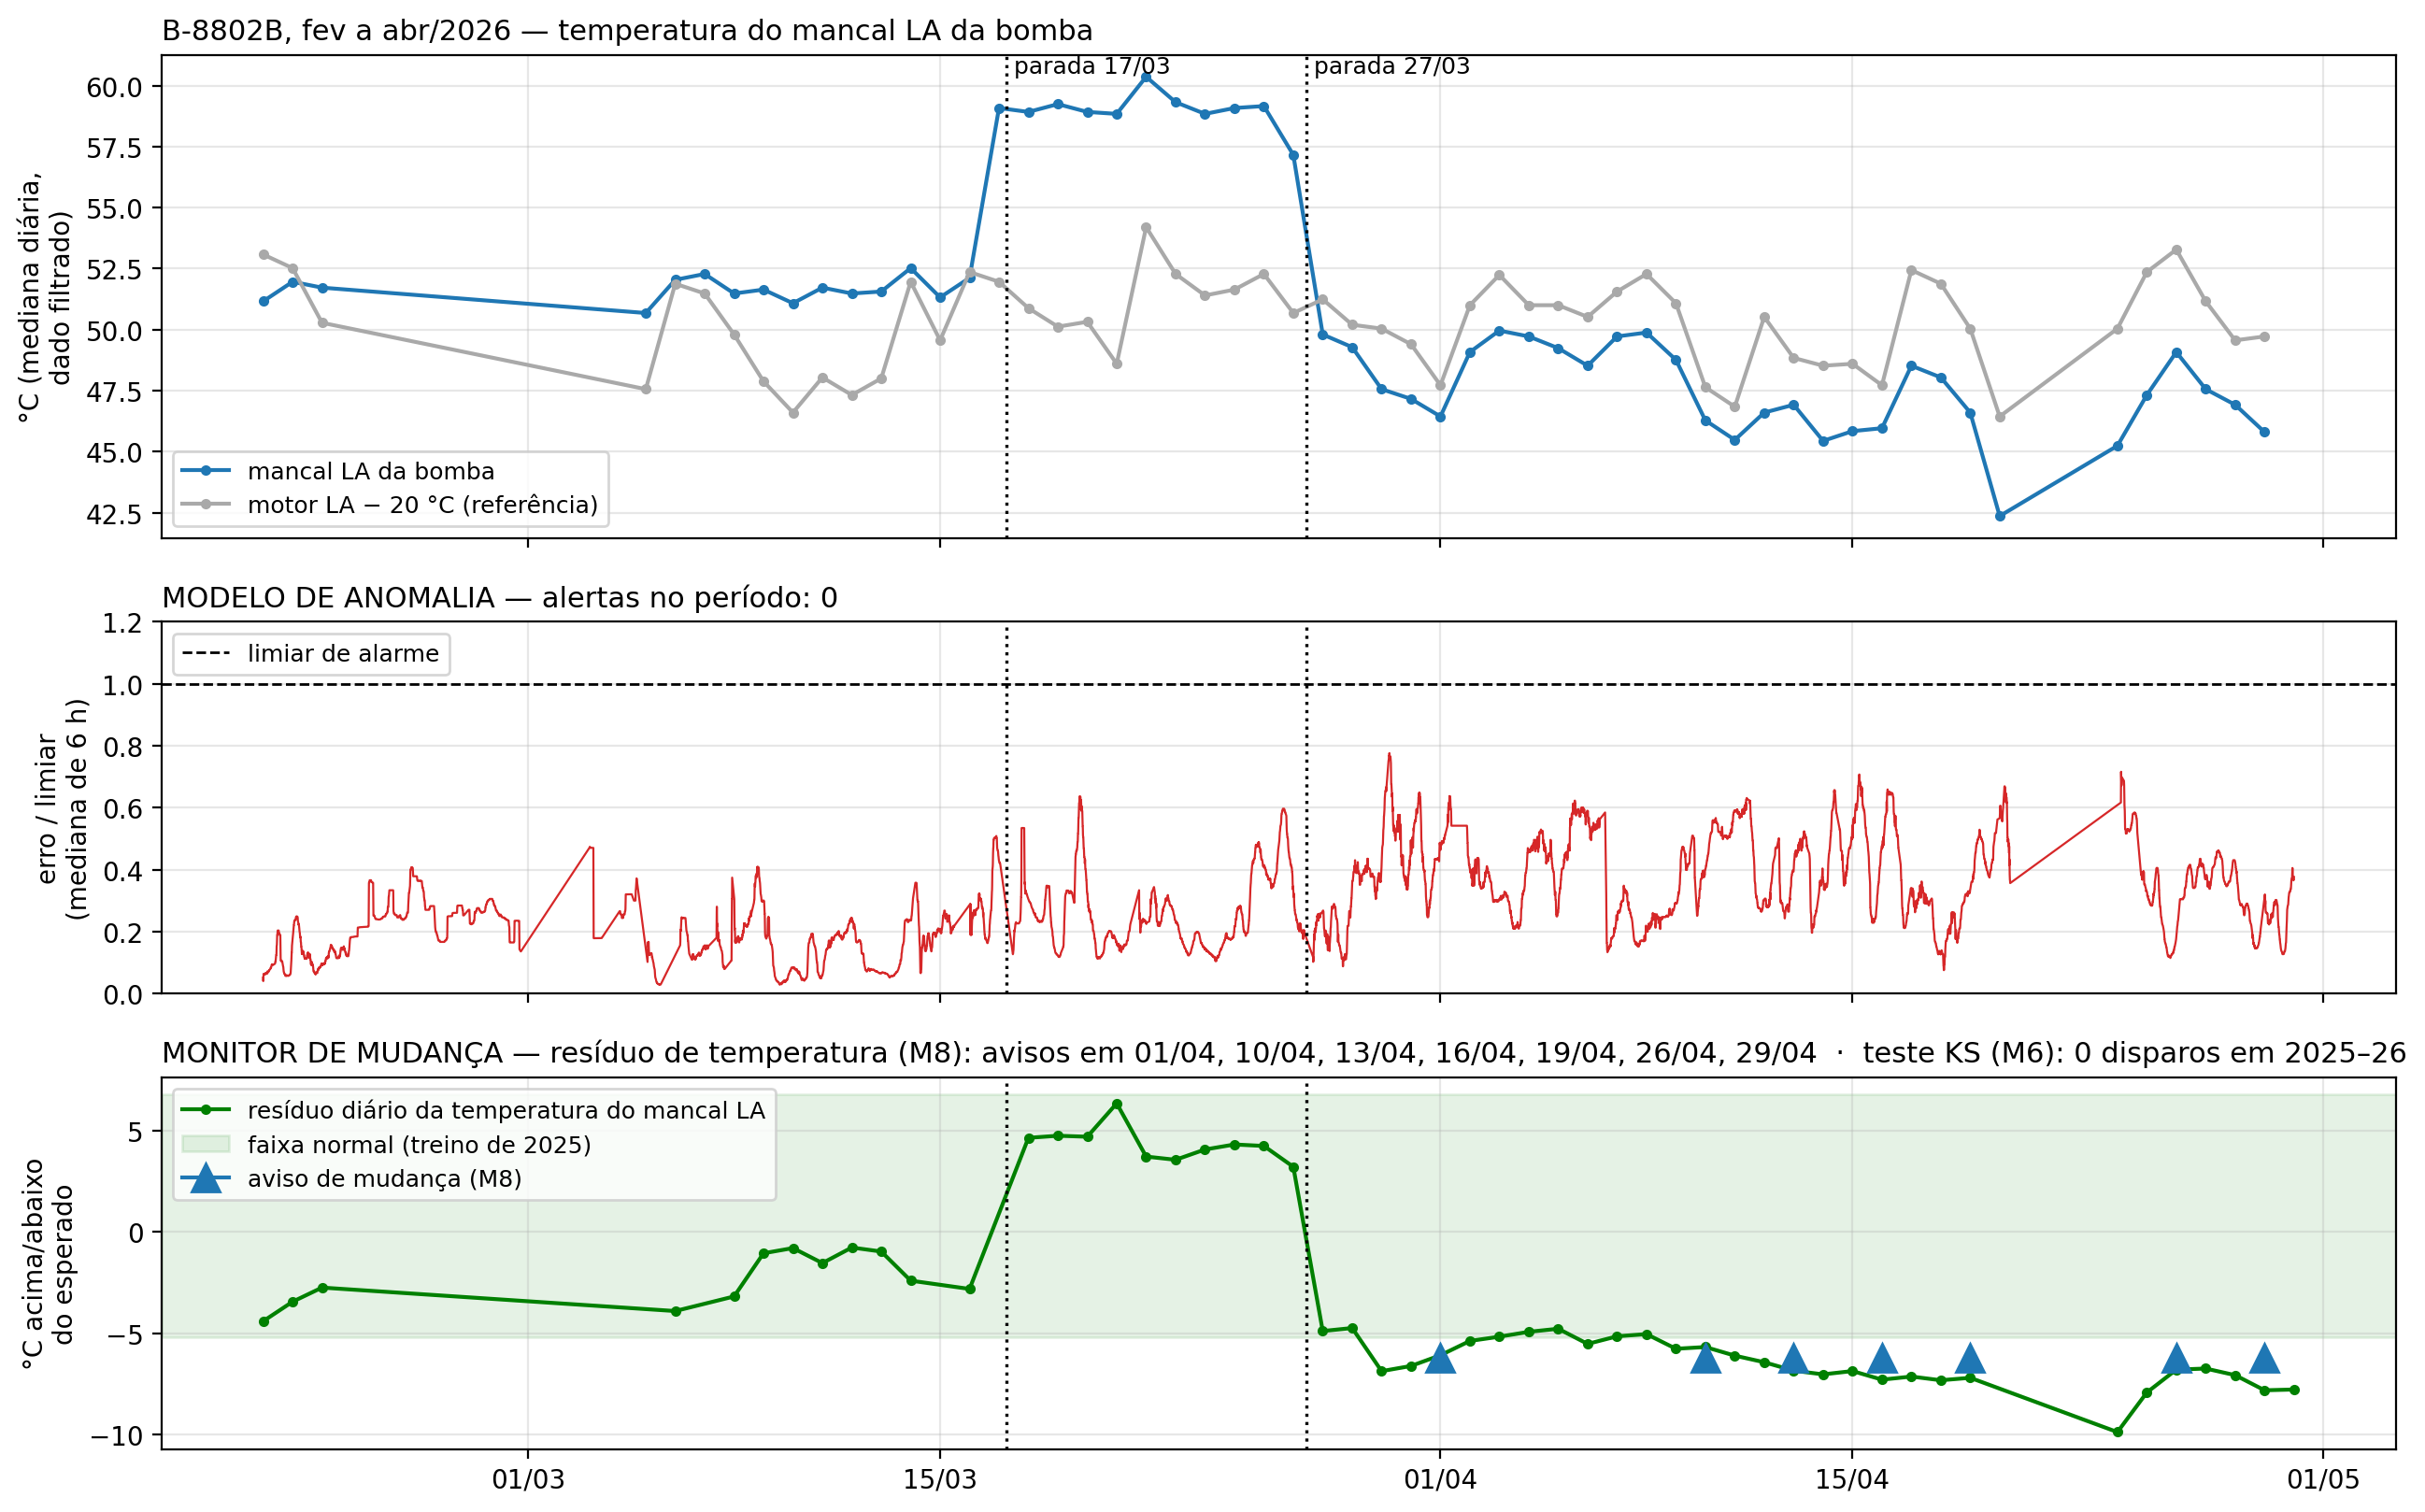

,01–16/03,18–26/03,28/03–30/04
mancal LA (°C),51.6,59.1,47.7
motor LA (°C),68.5,71.1,70.2
vibração LA (mm/s),2.55,2.38,2.13
modelo: maior erro diário / limiar,0.32,0.42,0.57
M8: resíduo diário (°C),-3.9 a -0.8,+3.2 a +6.4,-9.9 a -4.7


In [6]:
from transpetro_modelos.drift.residuo import ResidualLevelDetector
B_PROD = DEP / "B-8802B-2025/modelos/model_2025-01-01_2026-08-10_VAE"     # modelo em produção
P17, P27 = pd.Timestamp("2026-03-17 06:00"), pd.Timestamp("2026-03-27 11:00")
ini, fim = pd.Timestamp("2026-02-20"), pd.Timestamp("2026-04-30")
seg = raw.loc[ini - pd.Timedelta(days=1): fim]
rv = si.prever(B_PROD, si.carregar_modelo(B_PROD), si.preprocessar(B_PROD, seg), df_bruto=seg).loc[ini:fim]
lim = json.loads((B_PROD / "alarm.json").read_text())["threshold"]
det8 = ResidualLevelDetector.from_dict(json.loads((B_PROD / "residual_ref.json").read_text())["detectors"][0])
df8 = mon._sem_congelado(B_PROD, mon._temporal_steps(B_PROD, raw, todos_sensores=True))
res8, fires8 = det8.scan(df8); res8 = res8.loc[ini:fim]; fires8 = [t for t in fires8 if ini <= t <= fim]
ks = mon.ks_daily_fires(DADOS, B_PROD)

# o mesmo dado que o modelo e o monitor veem (depois de todos os filtros), só dias com >= 6 h de operação
filt = df8.loc[ini:fim, ["Temperatura Bomba LA", "Temperatura Motor LA", "Vibração Bomba LA"]]
dia = filt.resample("1D"); opd = dia.median()[dia.size() >= 72]
fig, axes = plt.subplots(3, 1, figsize=(13, 8.2), sharex=True, gridspec_kw={"height_ratios": [1.3, 1, 1]})
ax = axes[0]
ax.plot(opd.index, opd["Temperatura Bomba LA"], marker=".", color=AZUL, label="mancal LA da bomba")
ax.plot(opd.index, opd["Temperatura Motor LA"] - 20, marker=".", color=CINZA, label="motor LA − 20 °C (referência)")
ax.set_ylabel("°C (mediana diária,\ndado filtrado)"); ax.legend(loc="lower left", fontsize=9)
ax.set_title("B-8802B, fev a abr/2026 — temperatura do mancal LA da bomba", loc="left", fontsize=11)
ax = axes[1]
ax.plot(rv.index, rv["reconstruction_error"].rolling("6h").median() / lim, color=VERMELHO, linewidth=0.8)
ax.axhline(1, color="black", linestyle="--", linewidth=1, label="limiar de alarme")
ax.set_ylabel("erro / limiar\n(mediana de 6 h)"); ax.set_ylim(0, 1.2); ax.legend(loc="upper left", fontsize=9)
ax.set_title(f"MODELO DE ANOMALIA — alertas no período: {len(blocos(rv['alerta']))}", loc="left", fontsize=11)
ax = axes[2]
ax.plot(res8.index, res8.values, marker=".", color=VERDE, label="resíduo diário da temperatura do mancal LA")
ax.axhspan(*det8.band, color=VERDE, alpha=0.1, label="faixa normal (treino de 2025)")
for n, t in enumerate(fires8):
    ax.plot(t, det8.band[0] - 1, marker="^", markersize=11, color=AZUL, label="aviso de mudança (M8)" if n == 0 else None)
ax.set_ylabel("°C acima/abaixo\ndo esperado"); ax.legend(loc="upper left", fontsize=9)
ax.set_title(f"MONITOR DE MUDANÇA — resíduo de temperatura (M8): avisos em {', '.join(f'{t:%d/%m}' for t in fires8)}  ·  "
             f"teste KS (M6): {len(ks)} disparos em 2025–26", loc="left", fontsize=11)
for a in axes:
    for t in (P17, P27): a.axvline(t, color="black", linewidth=1.2, linestyle=":")
    a.grid(alpha=0.3)
axes[0].text(P17, axes[0].get_ylim()[1], " parada 17/03", va="top", fontsize=9); axes[0].text(P27, axes[0].get_ylim()[1], " parada 27/03", va="top", fontsize=9)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m")); plt.tight_layout(); plt.show()

per = {"01–16/03": ("2026-03-01", "2026-03-16 23:59"), "18–26/03": ("2026-03-18", "2026-03-27 08:00"), "28/03–30/04": ("2026-03-28", "2026-04-30")}
pd.DataFrame({k: {"mancal LA (°C)": round(filt.loc[a:b, "Temperatura Bomba LA"].median(), 1),
                  "motor LA (°C)": round(filt.loc[a:b, "Temperatura Motor LA"].median(), 1),
                  "vibração LA (mm/s)": round(filt.loc[a:b, "Vibração Bomba LA"].median(), 2),
                  "modelo: maior erro diário / limiar": round((rv.loc[a:b, "reconstruction_error"].resample("1D").median() / lim).max(), 2),
                  "M8: resíduo diário (°C)": f"{res8.loc[a:b].min():+.1f} a {res8.loc[a:b].max():+.1f}"}
              for k, (a, b) in per.items()})

**O que aconteceu:** o mancal LA ficou **~8 °C mais quente** depois da parada de 17/03 (51 → 59 °C, motor quase
igual) e, depois da parada de 27/03, **~4 °C mais frio que antes** (→ 48 °C). As duas viradas coincidem com as
paradas: parece intervenção no mancal LA (lubrificação, ajuste, troca) ou no sensor. **Pergunta à operação: o que
foi feito no mancal LA da bomba nas paradas de 17/03 e 27/03/2026?**

**O que cada detector viu:**
- **Modelo de anomalia:** nenhum alerta. 59 °C ainda está dentro do que o mancal faz no inverno de 2025
  (55 a 57 °C), e a vibração não acompanhou; sozinha, uma subida só de temperatura não basta para o modelo.
- **Teste KS (M6):** nenhum disparo em 2025–26 com o modelo em produção. Ele compara cada dia com o ano inteiro de
  treino, e a estação deixa a temperatura variar tanto que esse degrau não se destaca.
- **Resíduo de temperatura (M8):** **não** disparou no período quente (resíduo +3,6 a +6,4 °C, a faixa normal vai
  até +6,8), e disparou em **01/04** no período frio (resíduo abaixo de −5,2 °C).

**Ponto fraco encontrado:** um mancal 8 °C mais quente por 10 dias passou sem alerta e sem aviso. Vale avaliar um
limite mais apertado para o lado quente do M8, que é o lado que importa para falha.

## 5. Teste: janela deslizante × só dado depois da mudança (ClearML, task f65c0851)

Na mudança de março/2026, comparamos 4 formas de seguir, todas com a mesma grade de treino e o mesmo teste antes de
entrar (só modelo aprovado entra):

- **fixo:** fica o modelo de 12 meses (2025), sem retreino;
- **confirmação:** a política atual, só com dado depois de 28/03 (modelos com 1 e 3 meses);
- **misto:** nas mesmas datas, os últimos 12 meses (1 mês novo + 11 do ano anterior, depois 3 + 9);
- **deslizante:** os últimos 12 meses, refeito todo mês, sem esperar confirmação.

E um teste de **degradação lenta**: somamos à vibração do mancal LNA +0,15 mm/s por mês desde jan/2026 (≈ +1 mm/s em
agosto, o dobro do normal) e treinamos a janela deslizante com esse dado, como aconteceria na prática.

In [7]:
from transpetro_modelos.drift.retrain import aplicar_rampa
J = PROJECT_ROOT / "results/janela_deslizante"   # python scripts/janela_deslizante.py --baixar f65c0851c051403a87eb31f2ca1ee7c2
jr = pd.read_csv(J / "resumo.csv").set_index("nome")
M12, T_INI26, MUD = MODELO[12][0], pd.Timestamp("2026-01-06"), pd.Timestamp("2026-04-28")
rawR = aplicar_rampa(raw, "Vibração Bomba LNA:2026-01-06:0.15")
BJ = lambda n: (PROJECT_ROOT / jr.loc[n, "bundle"], pd.Timestamp(jr.loc[n, "treino_fim"]))
aprov = lambda pref: [BJ(n) for n in jr.index if n.startswith(pref) and jr.loc[n, "aprovado"]]
def cadeia(trocas, df):
    ag = [(M12, T_INI26)] + trocas
    return pd.concat([alerta(b, df, ini, ag[i + 1][1] - pd.Timedelta(minutes=1) if i + 1 < len(ag) else FIM) for i, (b, ini) in enumerate(ag)])
formas = {"fixo": [], "confirmação": [BJ("confirmacao_m01"), BJ("confirmacao_m03")], "misto": [BJ("misto_m01"), BJ("misto_m03")],
          "deslizante": [b for b in aprov("deslizante_2")]}
linhas = []
for nome, tr in formas.items():
    s = cadeia(tr, raw); d = s[s.index >= MUD]
    novos = [n for n in jr.index if n.startswith({"confirmação": "confirmacao", "misto": "misto", "deslizante": "deslizante_2"}.get(nome, "x"))]
    a22 = [len([t for t in blocos(alerta(PROJECT_ROOT / jr.loc[n, "bundle"], raw22).loc[:FALHA22 - pd.Timedelta(days=3)])]) for n in novos]
    linhas.append({"forma": nome, "modelos aprovados": f"{len(tr)} de {len(novos)}" if novos else "—",
                   "alertas falsos depois de 28/04/2026": len(blocos(d)),
                   "falha simulada: horas de antecedência": ", ".join(f"{jr.loc[n, 'sintetica_h']:.0f}" if pd.notna(jr.loc[n, "sintetica_h"]) and jr.loc[n, "sintetica_h"] > 0 else "não pega" for n in novos) or "—",
                   "alertas falsos no normal de 2022 (mai–jun)": ", ".join(map(str, a22)) or "0"})
pd.DataFrame(linhas).set_index("forma")

[rampa] Vibração Bomba LNA: +0.15/mês desde 2026-01-06 (até +1.07 no fim do dado)


,modelos aprovados,alertas falsos depois de 28/04/2026,falha simulada: horas de antecedência,alertas falsos no normal de 2022 (mai–jun)
forma,,,,
fixo,—,0,—,0
confirmação,2 de 2,2,"30, 17","17, 24"
misto,2 de 2,0,"7, 12","0, 1"
deslizante,4 de 7,0,"33, 21, 0, não pega, não pega, 10, não pega","0, 0, 0, 1, 0, 0, 1"


**Degradação lenta:** quanto do mês o sistema fica em alerta, com o modelo fixo (a política: o monitor avisa, a
operação diz que é defeito, não retreina) e com a janela deslizante (retreina todo mês com o dado que tiver).

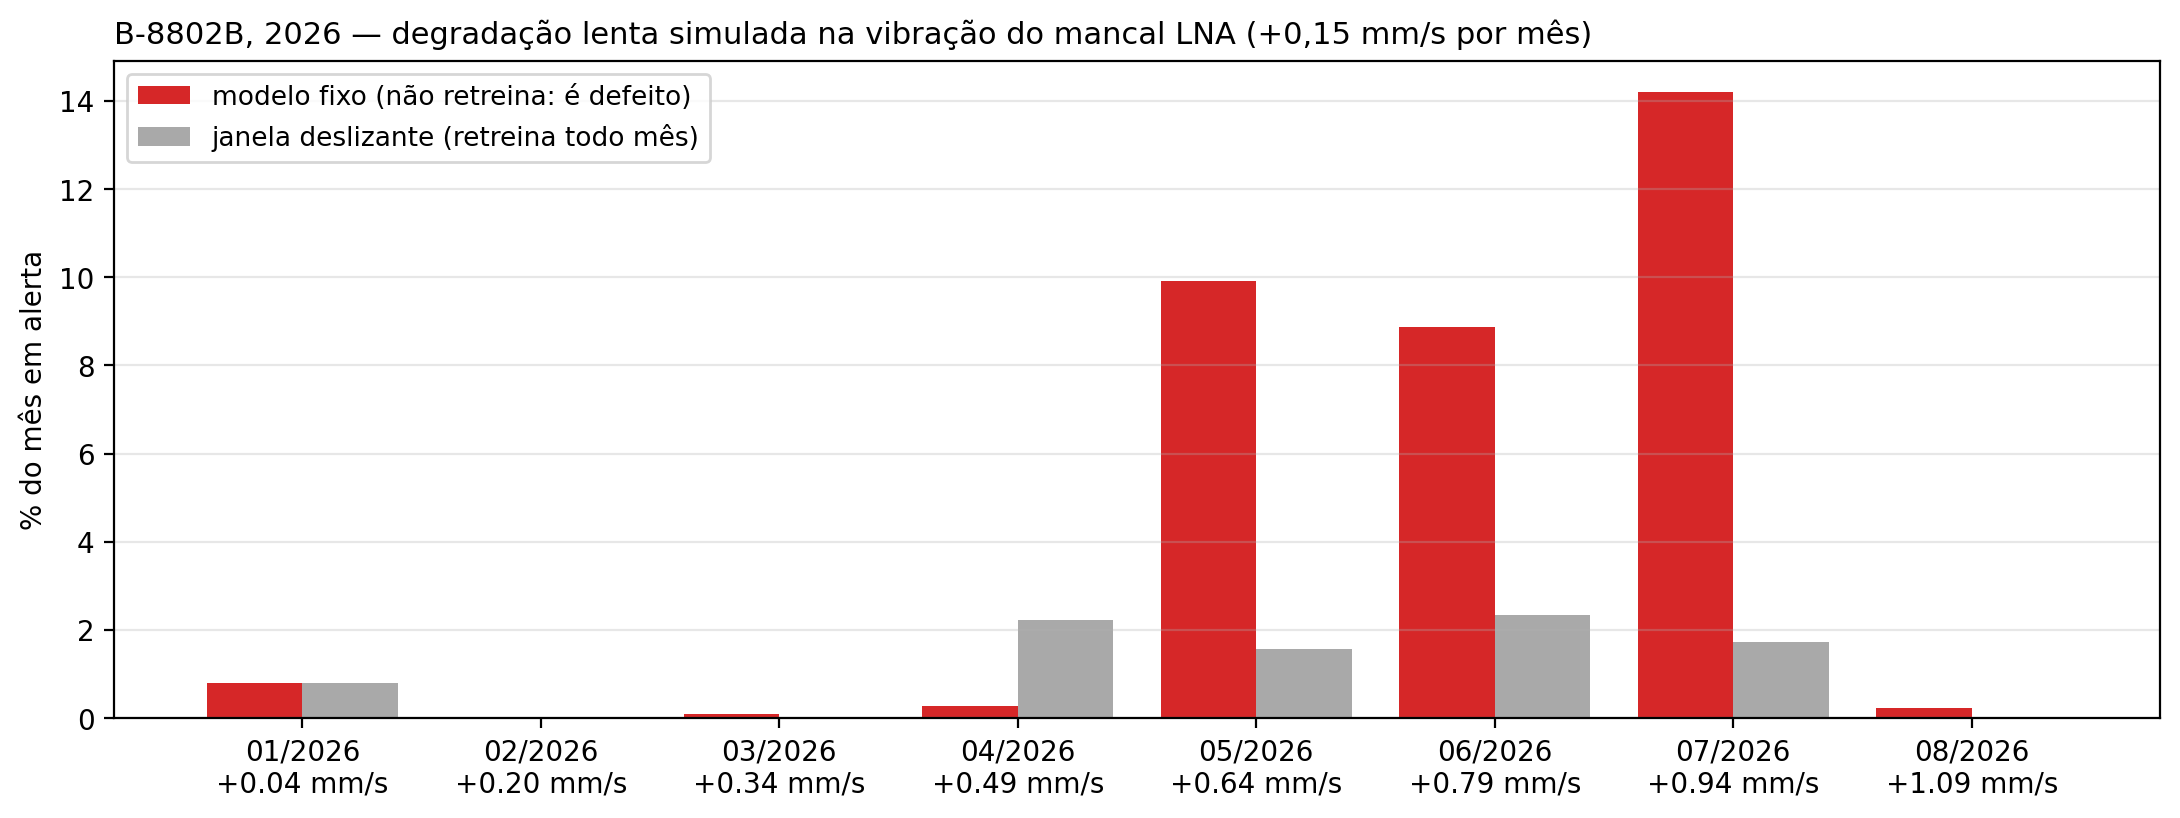

alertas de jan a ago/2026: fixo 54, deslizante 18 (sem a degradação: 2 e 2)


In [8]:
fixo = alerta(M12, rawR, T_INI26, FIM)
desl = cadeia(aprov("deslizante_rampa"), rawR)
m_f, m_d = 100 * fixo.resample("MS").mean(), 100 * desl.resample("MS").mean()
x = np.arange(len(m_f)); fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(x - 0.2, m_f.values, width=0.4, color=VERMELHO, label="modelo fixo (não retreina: é defeito)")
ax.bar(x + 0.2, m_d.reindex(m_f.index).values, width=0.4, color=CINZA, label="janela deslizante (retreina todo mês)")
rampa = [0.15 * max((t - T_INI26).days, 0) / 30.4 for t in m_f.index + pd.Timedelta(days=14)]
ax.set_xticks(x); ax.set_xticklabels([f"{t:%m/%Y}\n+{r:.2f} mm/s" for t, r in zip(m_f.index, rampa)])
ax.set_ylabel("% do mês em alerta"); ax.grid(alpha=0.3, axis="y"); ax.legend(loc="upper left", fontsize=9.5)
ax.set_title("B-8802B, 2026 — degradação lenta simulada na vibração do mancal LNA (+0,15 mm/s por mês)", loc="left", fontsize=11)
plt.tight_layout(); plt.show()
print(f"alertas de jan a ago/2026: fixo {len(blocos(fixo))}, deslizante {len(blocos(desl))} "
      f"(sem a degradação: {len(blocos(alerta(M12, raw, T_INI26, FIM)))} e {len(blocos(cadeia(aprov('deslizante_2'), raw)))})")

**Leitura:**
- **Nessa mudança de 2026, nenhuma forma precisava de retreino para evitar alerta falso:** o modelo fixo de 2025
  deu 0 alertas depois de 28/04. A mudança (mancal mais frio) ficou dentro do que o modelo já aceitava.
- **Só dado novo (confirmação) deixa o modelo estreito:** ele conhece só o regime frio de 2026 e alerta muito no
  normal de 2022; também deu 2 alertas falsos em junho/2026. É o mais sensível à falha simulada (17 a 30 h antes).
- **Misto (a ideia do 1 + 11) foi bem nesse caso:** 0 alertas falsos, 2022 limpo; perde um pouco de sensibilidade
  (7 a 12 h antes na falha simulada).
- **Janela deslizante sem confirmação:** em 3 dos 7 meses nenhum candidato pegou a falha simulada a tempo, e o
  principal: **ela aprende a degradação lenta.** Com o modelo fixo o alerta sobe para 9 % a 14 % do mês a partir de
  maio (+0,6 mm/s); com a janela deslizante fica em ~2 % e o sinal se dilui (agosto tem só 10 dias de dado). Na prática, com o modelo
  fixo o monitor também avisaria a mudança, a operação diria que é defeito, e não haveria retreino.

## 6. Em aberto

1. **Misto × só dado novo numa mudança grande:** o teste de 2026 foi uma mudança pequena. Numa mudança grande (como o
   B-4064A depois do reparo, +20 °C), os 11 meses velhos podem atrapalhar. Testar no B-4064A antes de decidir.
2. **Modelo × regra simples** em 2025–26: quantos alertas falsos cada um daria. É o que mostra se o modelo vale mais
   que um limite.
3. **Pergunta à operação:** o que foi feito nas paradas de 17/03 e 27/03/2026.

## 7. O que eu acho

- **A política funciona e é simples de operar:** de 269 alertas falsos para 3, e todos os modelos que entrariam em
  produção pegam a falha de 2022 quando ela começa. A confirmação da operação é o que impede o modelo de aprender
  defeito como normal.
- **1, 3, 6 e 12 meses é o calendário certo:** quase o mesmo resultado que todo mês, com bem menos trocas.
- **Janela deslizante automática, não:** ela aprende a degradação lenta como normal (alerta cai de ~10 % para ~2 %).
  A confirmação da operação continua necessária.
- **Retreinar só se a mudança gerar alerta falso:** em 2026 o modelo fixo não alertou à toa depois da mudança, então
  o aviso só precisa ser registrado. Proposta: confirmada a mudança, só retreina se o modelo atual estiver alertando.
- **Misto (1 + 11) é uma boa opção** para mudanças pequenas; para mudanças grandes, testar antes (item 1 em aberto).
- **O ponto fraco é o mês de transição** (do aviso ao modelo de 1 mês): precisa combinar com a operação como tratar
  esses alertas.
- **Não vender como "previsão com dias de antecedência":** o modelo detecta a anomalia quando ela aparece nos sensores.
  Na falha de 2022 isso deu 2 dias, porque ela levou 2 dias para quebrar.
- **Antes de integrar, vale fechar a comparação com a regra simples** (item 2): mostra onde o modelo realmente ajuda.